In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from scipy.ndimage import shift
from sunpy.physics.differential_rotation import solar_rotate_coordinate
from copy import deepcopy

In [1]:
tau=(3*10**15*1.38*10**(-23)*10**7*5*10**7*10**6)/(2/7*9*10**-12*(10**7)**3.5)
print(tau)

2.5456335164355446


In [4]:
a=2.35*10**(-2)*(23*10**8)**(5/6)*10**(-7/6)*10**(-10.4/6)
print(a)

1872.870399019516


In [ ]:
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\hmi.M_45s.20240618_210045_TAI.2.magnetogram.fits'
hmi_map=sunpy.map.Map(dir).rotate()

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(projection=hmi_map)
hmi_map.plot(axes=ax)

In [ ]:
bottom_left=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hmi_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hmi_map.coordinate_frame)
sub_hmi_map=hmi_map.submap(bottom_left,top_right=top_right)
fig=plt.figure()
ax=fig.add_subplot(projection=sub_hmi_map)
sub_hmi_map.plot(axes=ax)
plt.colorbar()
print(sub_hmi_map.data.min(),sub_hmi_map.data.max())

In [ ]:
def get_submap(map,x1,x2,y1,y2):
    xy1 = SkyCoord(x1*u.arcsec, y1*u.arcsec, frame=map.coordinate_frame)
    xy2 = SkyCoord(x2*u.arcsec, y2*u.arcsec, frame=map.coordinate_frame)
    submap = map.submap(xy1,top_right=xy2)
    return submap

def de_rotate(file,map_start,sub=False):
    if 'hmi' in file:
        map = sunpy.map.Map(file).rotate()
        print(111)
    else:
        map = sunpy.map.Map(file)
    center = map_start.center
    x0,y0 = map_start.wcs.world_to_pixel(center)
    new_coordinate = solar_rotate_coordinate(center,observer=map.observer_coordinate)
    if sub==False:
        dx = map_start.data.shape[1]*map_start.meta['cdelt1']
        dy = map_start.data.shape[0]*map_start.meta['cdelt1']
        x1,x2 = new_coordinate.Tx.value-dx/2,new_coordinate.Tx.value+dx/2
        y1,y2 = new_coordinate.Ty.value-dy/2,new_coordinate.Ty.value+dy/2
        sub_xy1 = SkyCoord(x1*u.arcsec, y1*u.arcsec, frame=map.coordinate_frame)
        sub_xy2 = SkyCoord(x2*u.arcsec, y2*u.arcsec, frame=map.coordinate_frame)
        map = map.submap(sub_xy1,top_right=sub_xy2)

    x1,y1 = map.wcs.world_to_pixel(new_coordinate)
    print(y0-y1,x0-x1)
    shifted_data = shift(deepcopy(map.data), [y0-y1,x0-x1],mode='nearest')
    newmeta = deepcopy(map.meta)
    newmap = sunpy.map.Map(shifted_data,newmeta)
    return newmap,shifted_data,map


In [ ]:
amap_=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T210044Z.131.image_lev1.fits')
ff=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\\'+'*.fits')
aia_map=de_rotate(ff[1],amap_,sub=False)
aia_map.plot()

In [ ]:
amap_=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\hmi.M_45s.20240618_210045_TAI.2.magnetogram.fits').rotate()

In [ ]:
ff=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\\'+'*.fits')
hmi_map,shifted_data,old_map=de_rotate(ff[0],amap_,sub=False)
plt.subplot(121)
plt.imshow(shifted_data,origin='lower',cmap='gray')
plt.subplot(122)
plt.imshow(old_map.data,origin='lower',cmap='gray')

In [ ]:
old_data=old_map.data
shf=shift(deepcopy(old_data),[0,0],mode='nearest')
plt.subplot(131)
plt.imshow(old_map.data,origin='lower',cmap='gray')
plt.subplot(132)
plt.imshow(old_data,origin='lower',cmap='gray')
plt.subplot(133)
plt.imshow(shf,origin='lower',cmap='gray')

In [ ]:
plt.imshow(old_data,origin='lower', cmap='gray')

In [ ]:
ff=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\\'+'*.fits')
for i in range(1):
    hmi_map=de_rotate(ff[i],amap_,sub=False)
    
    bottom_left=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hmi_map.coordinate_frame)
    top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hmi_map.coordinate_frame)
    sub_hmi_map=hmi_map.submap(bottom_left,top_right=top_right)
    fig=plt.figure()
    ax=fig.add_subplot(projection=sub_hmi_map)
    sub_hmi_map.plot(axes=ax)
    plt.colorbar()
    plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMIfig\\'+str(i).zfill(2)+'.png')
    plt.close()

In [ ]:
import sunpy.map
from sunpy.physics.differential_rotation import solar_rotate_coordinate
from astropy.coordinates import SkyCoord
from scipy.ndimage import shift
from copy import deepcopy
import numpy as np
import astropy.units as u

def de_rotate(file, map_start, sub=False):
    # 判断 HMI 图像是否需要旋转
    if 'hmi' in file:
        map_ = sunpy.map.Map(file).rotate()
        print('Rotated HMI map')
    else:
        map_ = sunpy.map.Map(file)
        
    # 目标中心点像素坐标
    center = map_start.center
    x0, y0 = map_start.wcs.world_to_pixel(center)
    
    # 目标中心旋转后的新坐标
    new_coordinate = solar_rotate_coordinate(center, observer=map_.observer_coordinate)
    
    if not sub:
        # 计算子图区域范围
        dx = map_start.data.shape[1] * map_start.meta['cdelt1']
        dy = map_start.data.shape[0] * map_start.meta['cdelt1']
        x1, x2 = new_coordinate.Tx.value - dx/2, new_coordinate.Tx.value + dx/2
        y1, y2 = new_coordinate.Ty.value - dy/2, new_coordinate.Ty.value + dy/2
        sub_xy1 = SkyCoord(x1 * u.arcsec, y1 * u.arcsec, frame=map_.coordinate_frame)
        sub_xy2 = SkyCoord(x2 * u.arcsec, y2 * u.arcsec, frame=map_.coordinate_frame)
        map_ = map_.submap(sub_xy1, top_right=sub_xy2)
    
    # 新中心像素坐标
    x1, y1 = map_.wcs.world_to_pixel(new_coordinate)
    
    # 处理 NaN：先转成 0，记录 mask
    data = map_.data
    nan_mask = np.isnan(data)
    data_no_nan = np.nan_to_num(data, nan=0.0)
    
    # 平移数据
    shifted_data = shift(data_no_nan, [y0 - y1, x0 - x1], mode='nearest')
    
    # 恢复 NaN
    shifted_data[nan_mask] = np.nan
    
    # 创建新 map
    new_meta = deepcopy(map_.meta)
    new_map = sunpy.map.Map(shifted_data, new_meta)
    
    return new_map
amap_ = sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\hmi.M_45s.20240618_211845_TAI.2.magnetogram.fits').rotate()
ff = glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\*.fits')



In [ ]:
sub_hmi_data=[]
for i in range(len(ff)):
    hmi_map = de_rotate(ff[i], amap_, sub=False)
    bottom_left = SkyCoord(Tx=200*u.arcsec, Ty=-520*u.arcsec, frame=hmi_map.coordinate_frame)
    top_right = SkyCoord(Tx=420*u.arcsec, Ty=-300*u.arcsec, frame=hmi_map.coordinate_frame)
    sub_hmi_map = hmi_map.submap(bottom_left, top_right=top_right)
    sub_hmi_data.append(sub_hmi_map)
    print(i)
    # fig = plt.figure()
    # ax = fig.add_subplot(projection=sub_hmi_map)
    # im=sub_hmi_map.plot(axes=ax)
    # im.set_clim(-2000, 2000)
    # plt.colorbar(im,ax=ax,label='Gauss')
    # plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMIfig\\' + str(i).zfill(2) + '.png')
    # plt.close()
np.save(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\HMI_submap.npy', sub_hmi_data)
#!!!这个

In [3]:
hmi1=fits.open(r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMI_prep\hmi0.fits')

In [6]:
print(hmi1[0].header)

SIMPLE  =                    T / Written by IDL:  Sun May 25 10:24:14 2025      BITPIX  =                  -32 /  IEEE single precision floating point          NAXIS   =                    2 / number of data axes                            NAXIS1  =                 4096 / Number of positions along axis 1               NAXIS2  =                 4096 / Number of positions along axis 2               EXTEND  =                    T / FITS dataset may contain extensions            COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H END                                                                                                                                                                                                                                                                                                                                                                     

In [5]:
hmi11=fits.open(r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\hmi.M_45s.20240618_210045_TAI.2.magnetogram.fits')
print(hmi11[1].header)

SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                   32 / data type of original image                    NAXIS   =                    2 / dimension of original image                    NAXIS1  =                 4096 / length of original image axis                  NAXIS2  =                 4096 / length of original image axis                  BLANK   =          -2147483648                                                  DATE    = '2024-06-22T10:46:37.000' / [ISO] HDU creation date                   DATE-OBS= '2024-06-18T20:59:53.400' / [ISO] Observation date {DATE__OBS}        TELESCOP= 'SDO/HMI '           / Telescope                                      INSTRUME= 'HMI_FRONT2'         / For HMI: HMI_SIDE1, HMI_FRONT2, or HMI_COMBINEDWAVELNTH=                6173. / [angstrom] Wavelength                          CAMERA  =                    2 / Camera                                         BUNIT   = 'Gauss   '           / Physica

In [6]:
hd1=hmi1[0].header
hd11=hmi11[1].header

In [28]:
hmi11.info()

Filename: D:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\hmi.M_45s.20240618_210045_TAI.2.magnetogram.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  COMPRESSED_IMAGE    1 CompImageHDU    110   (4096, 4096)   float64   


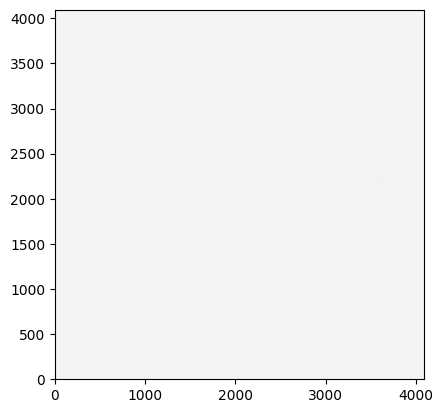

In [12]:
plt.imshow(np.rot90(np.rot90(hmi1[0].data,k=2),k=2),cmap='gray',origin='lower')
#plt.imshow(hmi1[0].data,cmap='gray',origin='lower')

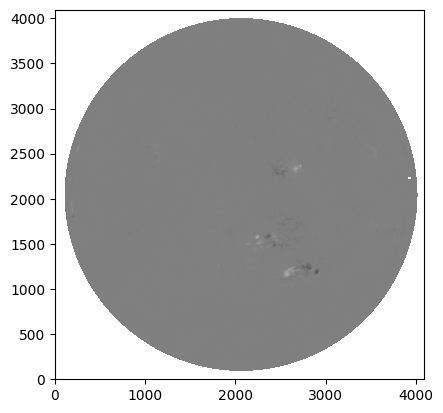

In [22]:
plt.imshow(np.rot90(hmi11[1].data,k=2),cmap='gray',origin='lower')

In [7]:
from astropy.io import fits

# 假设 data 是 ndarray，header 是 astropy.io.fits.Header 对象
hdu = fits.PrimaryHDU(data=np.rot90(hmi1[0].data,k=2), header=hmi11[1].header)
hdul = fits.HDUList([hdu])

# 保存
hdul.writeto(r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMI_prep\hmi00.fits', overwrite=True)


In [25]:
hmi=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\hmi.M_45s.20240618_211800_TAI.2.magnetogram.fits').rotate()

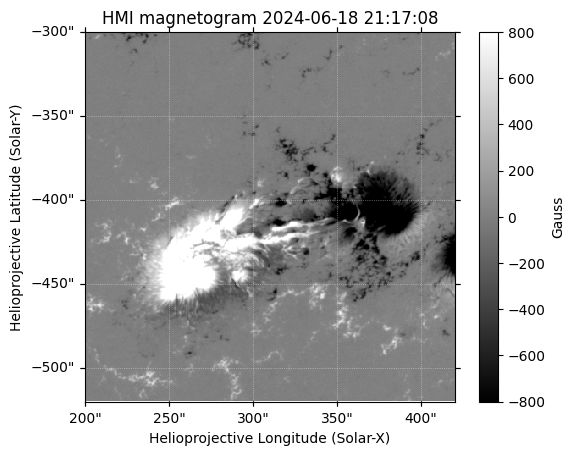

In [26]:
left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hmi.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hmi.coordinate_frame)
sub_hmi_map=hmi.submap(left_bottom,top_right=top_right)

left_bottom3=SkyCoord(Tx=205*u.arcsec,Ty=-450*u.arcsec,frame=hmi.coordinate_frame)
top_right3=SkyCoord(Tx=380*u.arcsec,Ty=-350*u.arcsec,frame=hmi.coordinate_frame)
fig=plt.figure()
ax=fig.add_subplot(projection=sub_hmi_map)
im=sub_hmi_map.plot(axes=ax)
#sub_hmi_map.draw_quadrangle(left_bottom3,top_right=top_right3,edgecolor='r')
im.set_clim(-800,800)
plt.colorbar(label='Gauss')

<font color=cyan>上面是一些尝试在IDL里旋转后保存为fits再用python处理，反正针对HMI的失败了，可能是旋转导致的，AIA估计可以</font>

In [2]:
dir_hmi=r'D:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\hmi.M_45s.20240618_211800_TAI.2.magnetogram.fits'
dir_131=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211756Z.131.image_lev1.fits'

hmi_map=sunpy.map.Map(dir_hmi).rotate()
aia_map=sunpy.map.Map(dir_131)

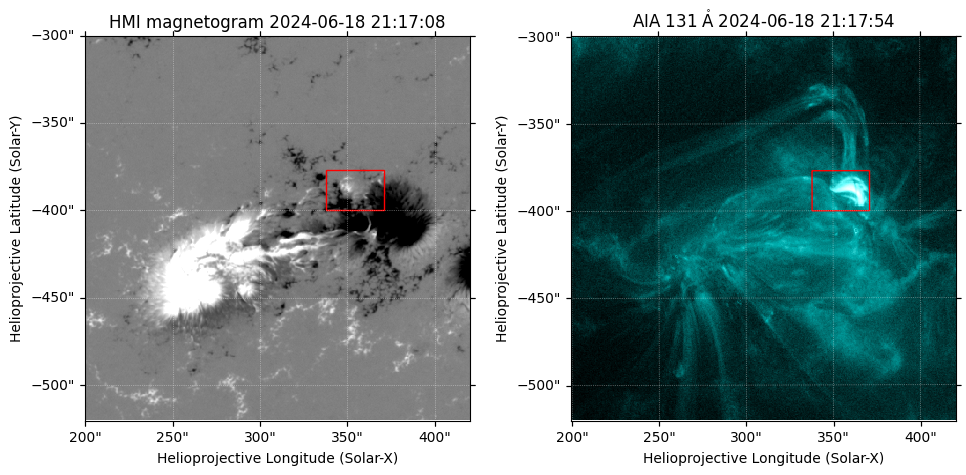

In [27]:
bottom_left=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hmi_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hmi_map.coordinate_frame)
sub_hmi_map=hmi_map.submap(bottom_left,top_right=top_right)
sub_aia_map=aia_map.submap(bottom_left,top_right=top_right)

# bottom_left2 = SkyCoord(Tx=340*u.arcsec, Ty=-397*u.arcsec, frame=hmi_map.coordinate_frame)
# top_right2 = SkyCoord(Tx=360*u.arcsec, Ty=-377*u.arcsec, frame=hmi_map.coordinate_frame)
bottom_left2=SkyCoord(Tx=338*u.arcsec,Ty=-400*u.arcsec,frame=hmi_map.coordinate_frame)
top_right2=SkyCoord(Tx=371*u.arcsec,Ty=-377*u.arcsec,frame=hmi_map.coordinate_frame)
#bottom_left2=SkyCoord(Tx=)
fig=plt.figure(figsize=(11.5,5))
ax1=fig.add_subplot(1,2,1,projection=sub_hmi_map)
im1=sub_hmi_map.plot(axes=ax1)
im1.set_clim(-800,800)
sub_hmi_map.draw_quadrangle(bottom_left2,top_right=top_right2,edgecolor='r')
#plt.colorbar(im1,ax=ax1)
ax2=fig.add_subplot(1,2,2,projection=sub_aia_map)
sub_aia_map.plot(axes=ax2)
sub_aia_map.draw_quadrangle(bottom_left2,top_right=top_right2,edgecolor='r')

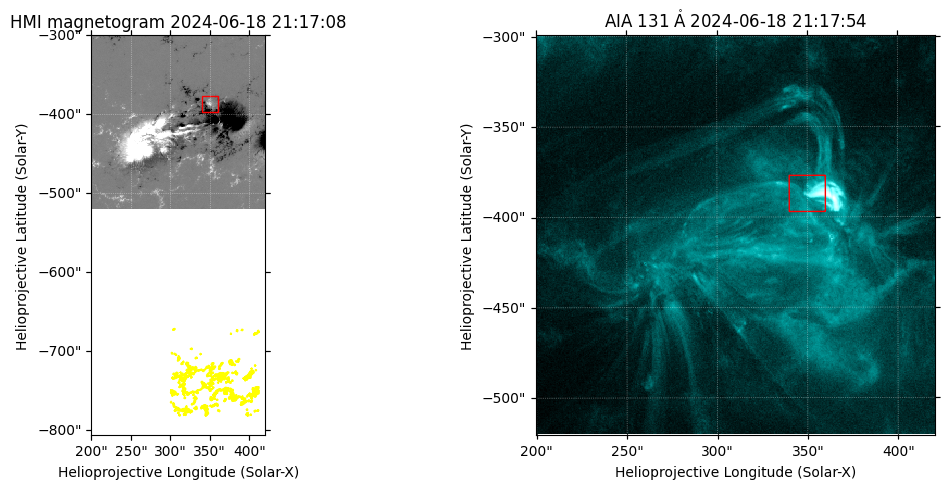

In [ ]:
bottom_left = SkyCoord(Tx=200*u.arcsec, Ty=-520*u.arcsec, frame=hmi_map.coordinate_frame)
top_right = SkyCoord(Tx=420*u.arcsec, Ty=-300*u.arcsec, frame=hmi_map.coordinate_frame)
sub_hmi_map = hmi_map.submap(bottom_left, top_right=top_right)
sub_aia_map = aia_map.submap(bottom_left, top_right=top_right)

bottom_left2 = SkyCoord(Tx=340*u.arcsec, Ty=-397*u.arcsec, frame=hmi_map.coordinate_frame)
top_right2 = SkyCoord(Tx=360*u.arcsec, Ty=-377*u.arcsec, frame=hmi_map.coordinate_frame)

fig = plt.figure(figsize=(11.5,5))
ax1 = fig.add_subplot(1,2,1, projection=sub_hmi_map)
im1 = sub_hmi_map.plot(axes=ax1)
im1.set_clim(-800,800)
sub_hmi_map.draw_quadrangle(bottom_left2, top_right=top_right2, edgecolor='r')
contours=sub_hmi_map.find_contours(level=100*u.gauss)

ax2 = fig.add_subplot(1,2,2, projection=sub_aia_map)
sub_aia_map.plot(axes=ax2)

# 把轮廓一条条画出来
for contour in contours:
    ax1.plot(contour.Tx.arcsec, contour.Ty.arcsec, color='yellow', linewidth=1.5)
# 在右图上绘制左图的等值线
sub_aia_map.draw_quadrangle(bottom_left2, top_right=top_right2, edgecolor='r')
plt.tight_layout()
plt.show()

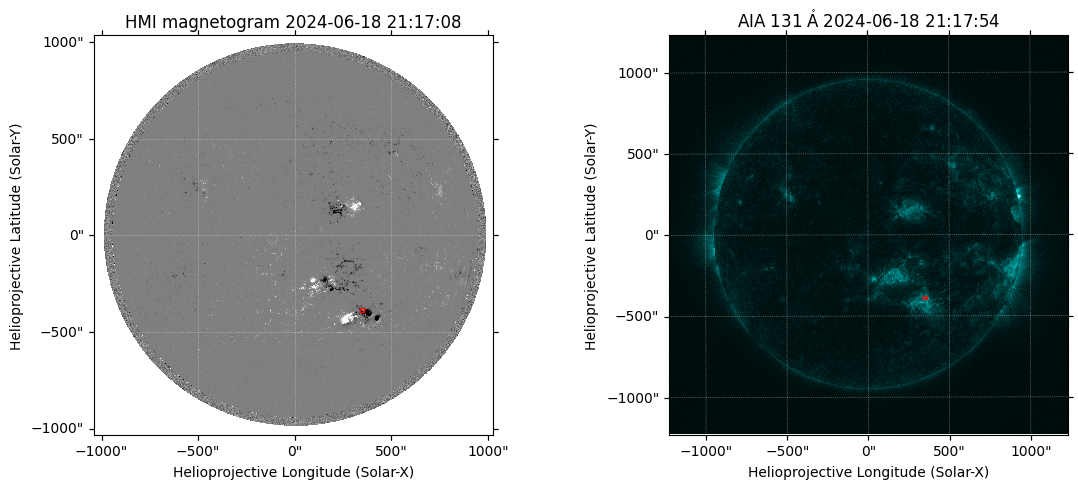

In [52]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord

# 获取子图区域
bottom_left = SkyCoord(Tx=200*u.arcsec, Ty=-520*u.arcsec, frame=hmi_map.coordinate_frame)
top_right = SkyCoord(Tx=420*u.arcsec, Ty=-300*u.arcsec, frame=hmi_map.coordinate_frame)
sub_hmi_map = hmi_map.submap(bottom_left, top_right=top_right)
sub_aia_map = aia_map.submap(bottom_left, top_right=top_right)

# 小红框区域
bottom_left2 = SkyCoord(Tx=340*u.arcsec, Ty=-397*u.arcsec, frame=hmi_map.coordinate_frame)
top_right2 = SkyCoord(Tx=360*u.arcsec, Ty=-377*u.arcsec, frame=hmi_map.coordinate_frame)

# 绘图
fig = plt.figure(figsize=(11.5, 5))

# 左图：HMI magnetogram
ax1 = fig.add_subplot(1, 2, 1, projection=hmi_map)
im1 = hmi_map.plot(axes=ax1)
im1.set_clim(-800, 800)
hmi_map.draw_quadrangle(bottom_left2, top_right=top_right2, edgecolor='r')

# 等值线（以像素为单位）
contours = sub_hmi_map.find_contours(level=100*u.G)



# 右图：AIA 131 Å 图像
ax2 = fig.add_subplot(1, 2, 2, projection=aia_map)
aia_map.plot(axes=ax2)
aia_map.draw_quadrangle(bottom_left2, top_right=top_right2, edgecolor='r')

for contour in contours:
    if contour.ndim == 2 and contour.shape[1] == 2:
        # 转换像素坐标到 SkyCoord 世界坐标
        y_pixels, x_pixels = contour[:, 0], contour[:, 1]
        sky_coords = sub_hmi_map.pixel_to_world(x_pixels * u.pixel, y_pixels * u.pixel)
        ax1.plot(sky_coords.Tx.arcsec, sky_coords.Ty.arcsec, color='yellow', linewidth=1.5)
        ax2.plot(sky_coords.Tx.arcsec, sky_coords.Ty.arcsec, color='yellow', linewidth=1.5)

plt.tight_layout()
plt.show()


In [51]:
print(f"找到的等值线数量: {len(contours)}")



找到的等值线数量: 271


<font color=cyan>感觉没对齐呢</font>

In [6]:
flux_cancellation=readsav(r'D:\Learning\PHD1st\magnetic_reconnecion\data_process\flux_cancellation.sav')
array_pos=flux_cancellation['array_pos']
array_neg=flux_cancellation['array_neg']

In [7]:
from datetime import datetime, timedelta

# 定义起始时间
start_time = datetime.fromisoformat('2024-06-18T20:59:53')
# 定义每次增加的时间间隔
interval = timedelta(seconds=45)

# 生成时间序列
time_sequence = []
for i in range(54):
    current_time = start_time + i * interval
    # 格式化时间为只显示到秒
    time_str = current_time.strftime('%Y-%m-%dT%H:%M:%S')
    time_sequence.append(time_str[-8:])
# 打印前10个时间字符串以验证
for time_str in time_sequence[:10]:
    print(time_str)

20:59:53
21:00:38
21:01:23
21:02:08
21:02:53
21:03:38
21:04:23
21:05:08
21:05:53
21:06:38


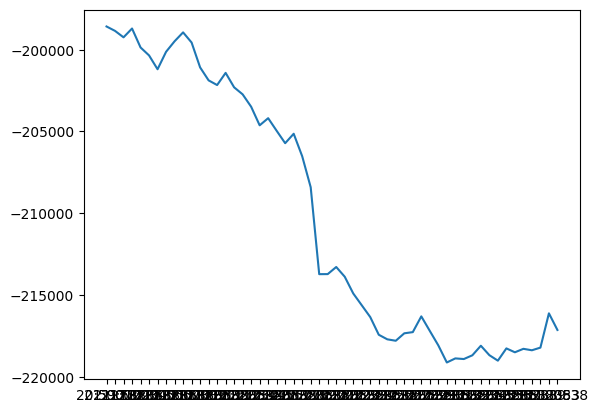

In [17]:
plt.plot(time_sequence,array_neg)

In [1]:
import numpy as np
l=151963542123.29977*100
r=l*np.sin(np.pi/(3600*180))
cm2=(r*0.504)**2
print(cm2)

1378763006944252.8


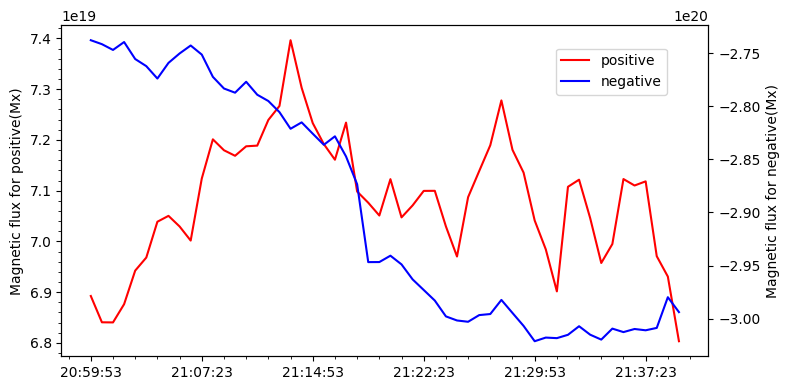

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
l=151963542123.29977*100
r=l*np.sin(np.pi/(3600*180))
cm2=(r*0.504)**2
fig, ax1 = plt.subplots(figsize=(8,4))

ax1.plot(time_sequence, array_pos*cm2,c='r',label='positive')
ax1.set_ylabel('Magnetic flux for positive(Mx)')

# 控制 x 轴最多 5 个刻度
ax1.xaxis.set_major_locator(MaxNLocator(nbins=6))
ax1.minorticks_on()
#plt.xticks(rotation=45)
ax2=ax1.twinx()
ax2.plot(time_sequence, array_neg*cm2,c='blue',label='negative')
ax2.set_ylabel('Magnetic flux for negative(Mx)')
fig.legend(loc='upper center',bbox_to_anchor=(0.85,0.95), bbox_transform=ax1.transAxes)
plt.tight_layout()
plt.show()


AttributeError: 'str' object has no attribute 'strftime'

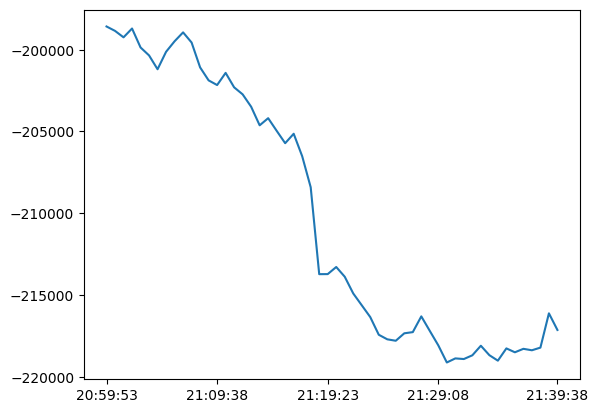

In [18]:
import numpy as np

fig, ax = plt.subplots()

ax.plot(time_sequence, array_neg)

# 取 5 个位置
indices = np.linspace(0, len(time_sequence)-1, 5, dtype=int)
ax.set_xticks([time_sequence[i] for i in indices])
ax.set_xticklabels([time_sequence[i].strftime('%H:%M:%S') for i in indices])

plt.xticks(rotation=45)
plt.xlabel('Time')
plt.ylabel('Value')
plt.tight_layout()
plt.show()
